# Part 1: Baseline Models

This notebook trains and evaluates the two baselines for Part 1: a majority-class floor and a TF-IDF plus Logistic Regression classifier, both on the shared stratified split. Every output is followed by an explanation, so this notebook can be read on its own when writing the report.

Both models are scored with `src/metrics.py`, the same evaluation code every other part of the project uses, so these numbers are directly comparable to the neural models built in Parts 2 through 4.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

from src.baselines import load_train_val, run_majority_baseline, run_tfidf_logreg

train, val = load_train_val()
print(f'train size: {len(train)}')
print(f'val size: {len(val)}')

train size: 27755
val size: 5947


**What this shows:** 27,755 training rows and 5,947 validation rows, matching the 70/15 portion of the shared stratified split confirmed earlier in `src/data_prep.py`.

## Majority-class baseline

This model predicts the single most frequent training label, `sexual_violence`, for every example. It exists to make the class imbalance concrete: it is the floor any real model must clear, not a competitive model in its own right.

Model: majority_baseline
Accuracy (leaderboard metric): 0.8234
Macro F1: 0.1806
Weighted F1: 0.7437

Per-class precision / recall / F1 / support:
  economic_violence              precision=0.000  recall=0.000  f1=0.000  support=33
  emotional_violence             precision=0.000  recall=0.000  f1=0.000  support=97
  harmful_traditional_practice   precision=0.000  recall=0.000  f1=0.000  support=28
  physical_violence              precision=0.000  recall=0.000  f1=0.000  support=892
  sexual_violence                precision=0.823  recall=1.000  f1=0.903  support=4897


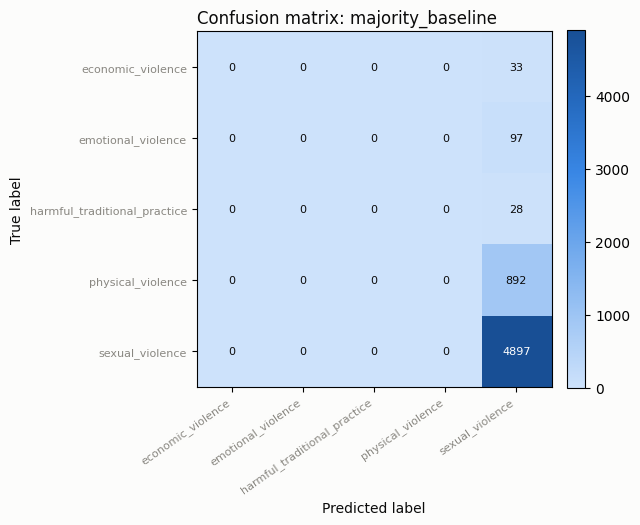

In [2]:
majority_metrics = run_majority_baseline(train, val)

**What this shows:** accuracy is 0.8234, matching the class distribution found in the EDA exactly, since this model always predicts `sexual_violence`. Macro F1 collapses to 0.1806, and every class other than `sexual_violence` scores exactly zero precision, recall, and F1. This is the numerical proof of the point made in Part 1's EDA: accuracy alone would call this an 82% correct model, while it has learned nothing at all about four of the five categories.

## TF-IDF and Logistic Regression

This model represents each tweet as TF-IDF weighted unigrams and bigrams, then classifies with logistic regression using balanced class weights, chosen specifically because an unweighted model would likely default toward the majority class given the same imbalance documented in the EDA.

Model: tfidf_logreg
Accuracy (leaderboard metric): 0.9970
Macro F1: 0.9841
Weighted F1: 0.9970

Per-class precision / recall / F1 / support:
  economic_violence              precision=0.943  recall=1.000  f1=0.971  support=33
  emotional_violence             precision=0.915  recall=1.000  f1=0.956  support=97
  harmful_traditional_practice   precision=1.000  recall=1.000  f1=1.000  support=28
  physical_violence              precision=0.997  recall=0.996  f1=0.996  support=892
  sexual_violence                precision=0.999  recall=0.997  f1=0.998  support=4897


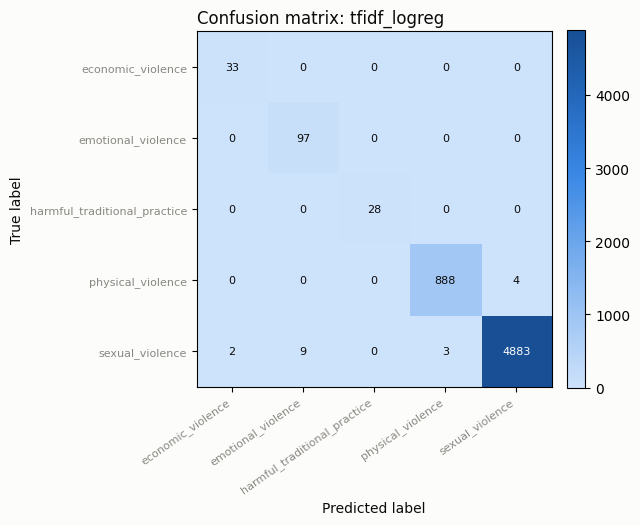

In [3]:
tfidf_metrics = run_tfidf_logreg(train, val)

**What this shows:** accuracy reaches 0.9970 and macro F1 reaches 0.9841, with every class scoring above 0.94 on precision, recall, and F1, including the two rarest classes. This is a strikingly strong result for a linear bag-of-words model on a 5-class problem, high enough that it needs to be investigated rather than simply reported. The investigation immediately below explains why.

## Why the TF-IDF baseline scores this high

The challenge brief explicitly frames this task as classification "without using keywords." A near-perfect linear bag-of-words model is a signal that the categories may be separable by a small set of near-deterministic trigger words, which is exactly the shortcut the brief warns against. This is checked directly below by reading off the highest-weighted features the trained model actually relies on for each class.

In [4]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from src.data_prep import ID_TO_LABEL

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X = vec.fit_transform(train['tweet_clean'])
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X, train['label_id'])

feature_names = np.array(vec.get_feature_names_out())
for class_id in range(5):
    top_idx = np.argsort(clf.coef_[class_id])[-10:][::-1]
    print(f"{ID_TO_LABEL[class_id]}: {list(feature_names[top_idx])}")

economic_violence: ['fired', 'job', 'because', 'woman', 'was fired', 'fired from', 'was', 'job because', 'my job', 'boss']
emotional_violence: ['public', 'humiliated', 'insulted', 'in public', 'in', 'verbally', 'humiliated me', 'the public', 'insulted me', 'verbally abused']
harmful_traditional_practice: ['forced', 'fgm', 'marriage', 'child marriage', 'undergo', 'genital mutilation', 'genital', 'female genital', 'mutilation', 'child']
physical_violence: ['beats', 'husband', 'my husband', 'beats me', 'my', 'husband beats', 'he beats', 'beats the', 'beats her', 'wife']
sexual_violence: ['raped', 'he', 'raped me', 'he raped', 'was raped', 'rape', 'raped and', 'raped by', 'me', 'raped her']


**What this shows:** the top features driving each class are close to literal trigger words. `raped` and `rape` drive `sexual_violence`, `fgm`, `mutilation`, and `child marriage` drive `harmful_traditional_practice`, `beats` and `husband` drive `physical_violence`, `fired`, `job`, and `boss` drive `economic_violence`, and `humiliated`/`insulted` drive `emotional_violence`. This confirms the model is closer to a keyword lookup table than to genuine language understanding, and it explains the near-perfect score directly: this dataset's categories are largely separable by a narrow, learnable vocabulary.

This has a direct consequence for the rest of the project. This TF-IDF baseline is not a weak strawman to be easily beaten; on this validation set it may be difficult for any model to substantially outscore it on accuracy or macro F1 using the same kind of evaluation. The genuinely useful comparison for the neural models in Parts 2 through 4 is therefore not only the headline metric, but whether they generalize better than this baseline on the harder subset of examples that do not contain an obvious trigger word, an angle worth building into the shared error analysis in a later stage.

## Summary: what this means going forward

The majority-class baseline confirms, numerically, that accuracy alone is not a trustworthy metric on this dataset. The TF-IDF and Logistic Regression baseline is unexpectedly strong, and the reason is traceable directly to a small set of near-deterministic keywords per class, exactly the shortcut the challenge brief warns against. Both results are saved to `reports/results/` in the shared JSON format, and both confusion matrices are saved to `reports/figures/`, ready for the five-model comparison in the Results and Visualizations stage. The most important open question this raises for Parts 2 through 4 is not whether a neural model can beat this baseline's headline score, but whether it can do something this baseline structurally cannot: generalize to tweets that describe these categories without using the obvious trigger words.